### What Makes Hierarchical Clustering Different?
K-Means produces:
```
Cluster 1
Cluster 2
Cluster 3
```
Final answer only.

Hierarchical Clustering produces:
```
Hierarchy of clusters
```
Like a family tree.

Example:
```
Animals
│
├── Mammals
│   ├── Dogs
│   └── Cats
│
└── Birds
    ├── Eagle
    └── Sparrow
```
This hierarchy is valuable.

### Core Idea
Build clusters in stages.

Two approaches:

**1. Agglomerative Clustering**

Bottom-Up

Starts with:
```
Every point = One cluster
```
Then repeatedly merges closest clusters.

**2. Divisive Clustering**

Top-Down

Starts with:
```
All points together
```
Then repeatedly splits.

#### 1. Agglomerative Clustering
Most common.

Starts with:
```
Every point = one cluster
```
Then repeatedly:
```
Merge nearest clusters
```
until all points belong to one cluster.

Example:

Initially:
```
A   B   C   D
```
Step 1:
```
(A,B)   C   D
```
Step 2:
```
(A,B)   (C,D)
```
Step 3:
```
(A,B,C,D)
```
Hierarchy created.

#### Divisive Clustering
Opposite strategy.

Start:
```
(A,B,C,D)
```
Split:
```
(A,B)   (C,D)
```
Split again:
```
A B C D
```
Works well theoretically.

Less common due to computational cost.

### Agglomerative Clustering Workflow
Suppose data points:
```
A
B
C
D
```

#### Step 1
Treat every point as individual cluster.
```
{A}
{B}
{C}
{D}
```

#### Step 2
Calculate distances.

Distance Matrix:
```
      A   B   C   D
A     0
B     2   0
C     8   7   0
D     9   8   3   0
```

Smallest distance:
```
A-B = 2
```
Merge:
```
{AB}
{C}
{D}
```

#### Step 3
Recompute distances.
```
{AB}
{C}
{D}
```

Find closest clusters.

Suppose:
```
C-D = 3
```
Merge:
```
{AB}
{CD}
```

#### Step 4
Merge remaining clusters.
```
{ABCD}
```
Hierarchy complete.

### Distance Matrix
Hierarchical clustering relies heavily on distances.

Suppose:

Points:
```
A
B
C
```

Distance matrix:
|   | A | B | C |
| - | - | - | - |
| A | 0 | 2 | 8 |
| B | 2 | 0 | 7 |
| C | 8 | 7 | 0 |

Nearest pair:
```
A and B
```
Merge first.

#### Metrics Used
##### 1. Euclidean Distance
$$
d(x, y) = \sqrt {\sum {(x_i - y_i)}^2}
$$

##### 2. Manhattan Distance
$$
d(x, y) = \sum {|x_i - y_i|}
$$

##### 3. Cosine Distance

Used for text embeddings.

Measures angle between vectors.

Popular in:
- NLP
- Semantic Search
- Recommendation Systems

### Dendrogram
Most important visualization.

A dendrogram is:
> A tree showing how clusters merge.

A **dendrogram** is a **tree-like diagram** used to visualize the results of **Hierarchical Clustering**.

It shows:
- Which data points are grouped together.
- In what order clusters are formed.
- At what distance (or similarity level) clusters merge.

Example:

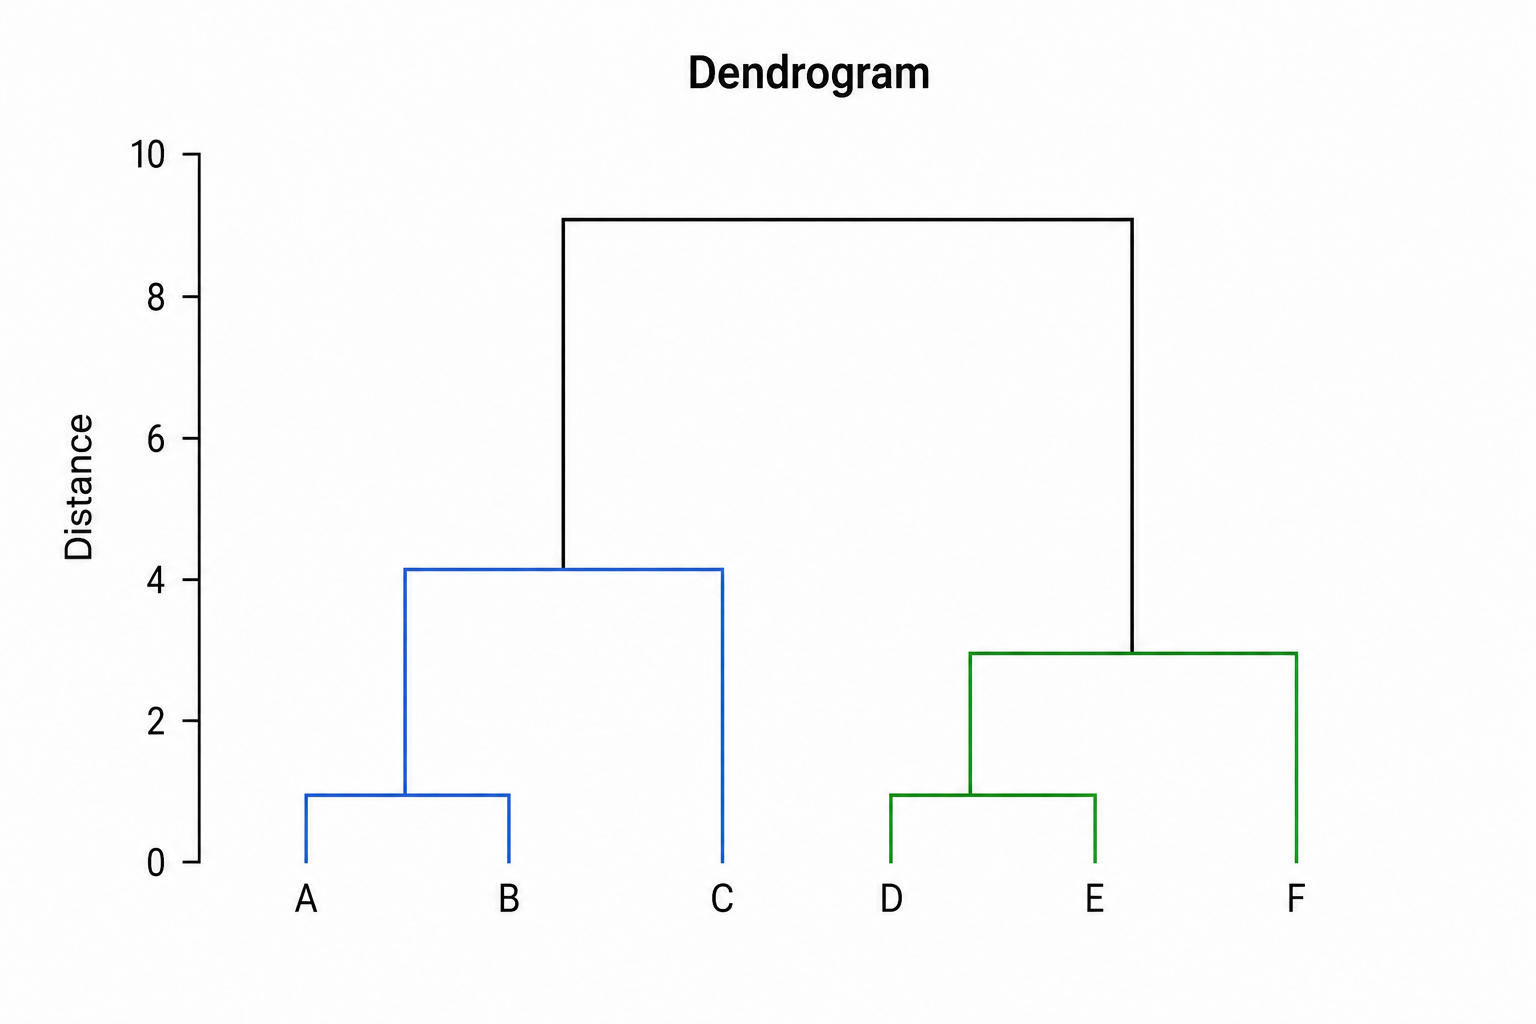

Bottom:

Individual observations.

Top:

One giant cluster.

### Understanding Merge Height
A dendrogram is essentially a **history of cluster merging.**

The height at which two clusters join represents the **distance (dissimilarity)** between those clusters at the moment they are merged.

##### Example 1: Low Merge Height = Very Similar

Consider these 1D data points:
```
A = 10
B = 11
C = 50
```

Distances:
```
Distance(A,B) = 1
Distance(A,C) = 40
Distance(B,C) = 39
```

Step 1:
```
A and B merge
```
because distance = 1

The merge occurs at height = 1.

This indicates:
```
A and B are very similar.
```

##### Example 2: High Merge Height = Less Similar
After A and B form a cluster:
```
(A,B) = {10,11}
```
Now compare:
```
(A,B) cluster ↔ C
```
Distance is approximately:
```
39–40
```
Therefore:
```
(A,B) and C merge at height 40
```
```
Height = 40
```
This large height means:
```
The two clusters are quite different.
```

**Dendrogram**

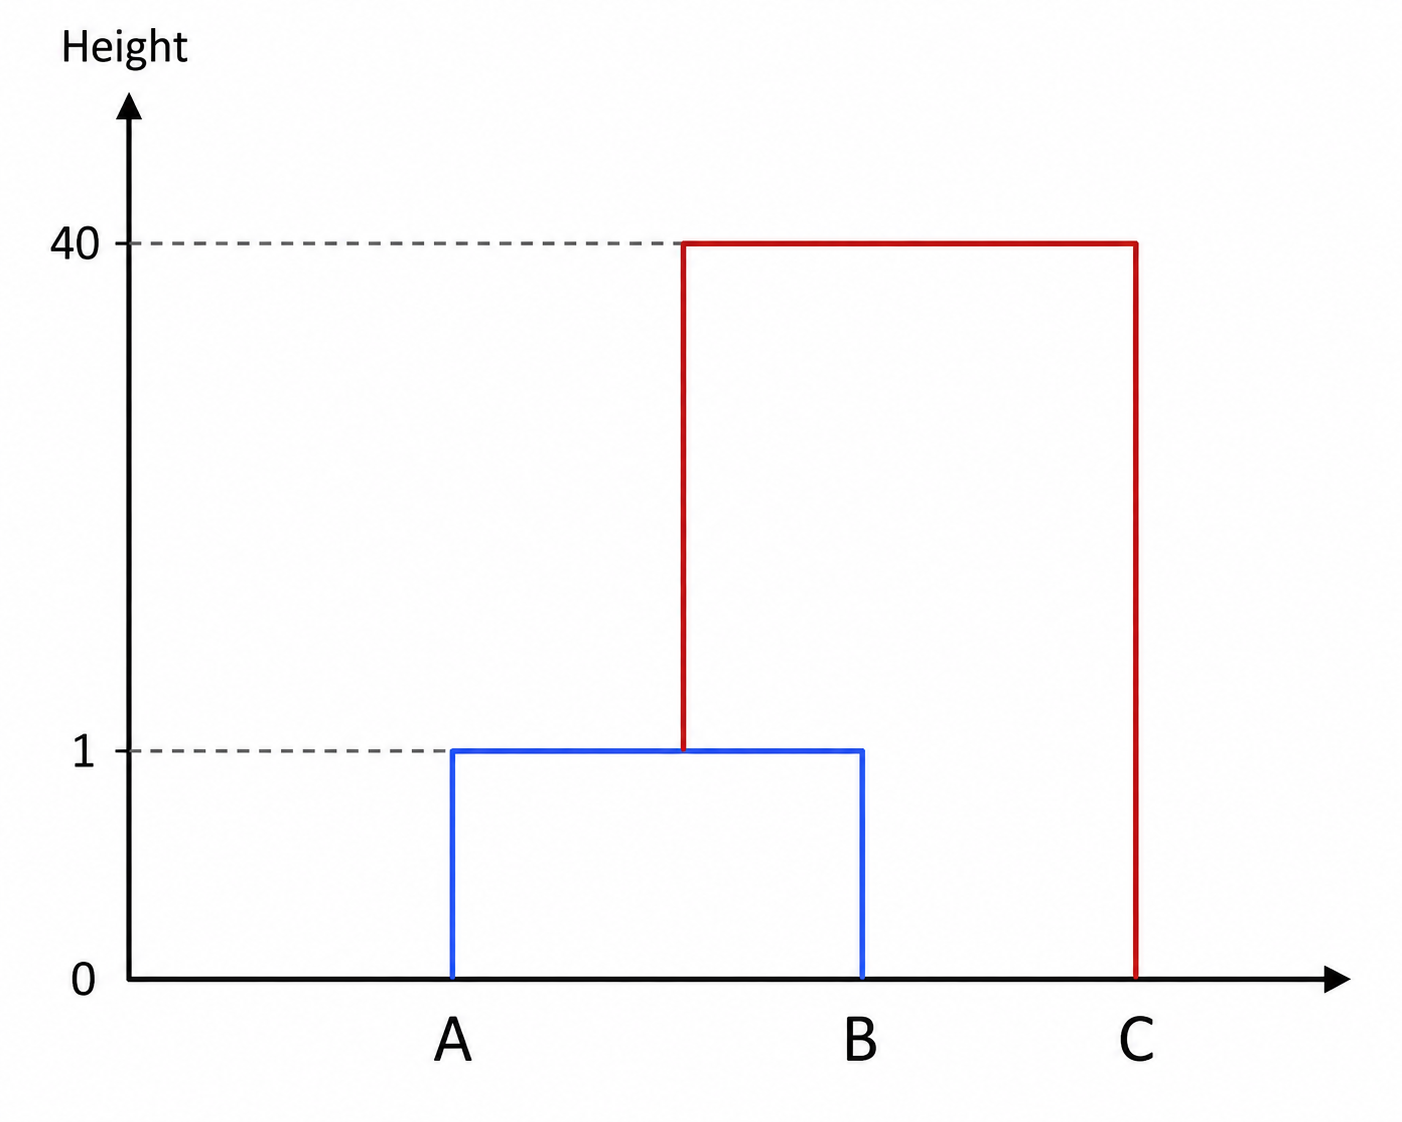

### Choosing Number of Clusters
Unlike K-Means:

No K required initially.

Build full hierarchy.

Then:
```
Cut dendrogram
```
at chosen height.

Example:

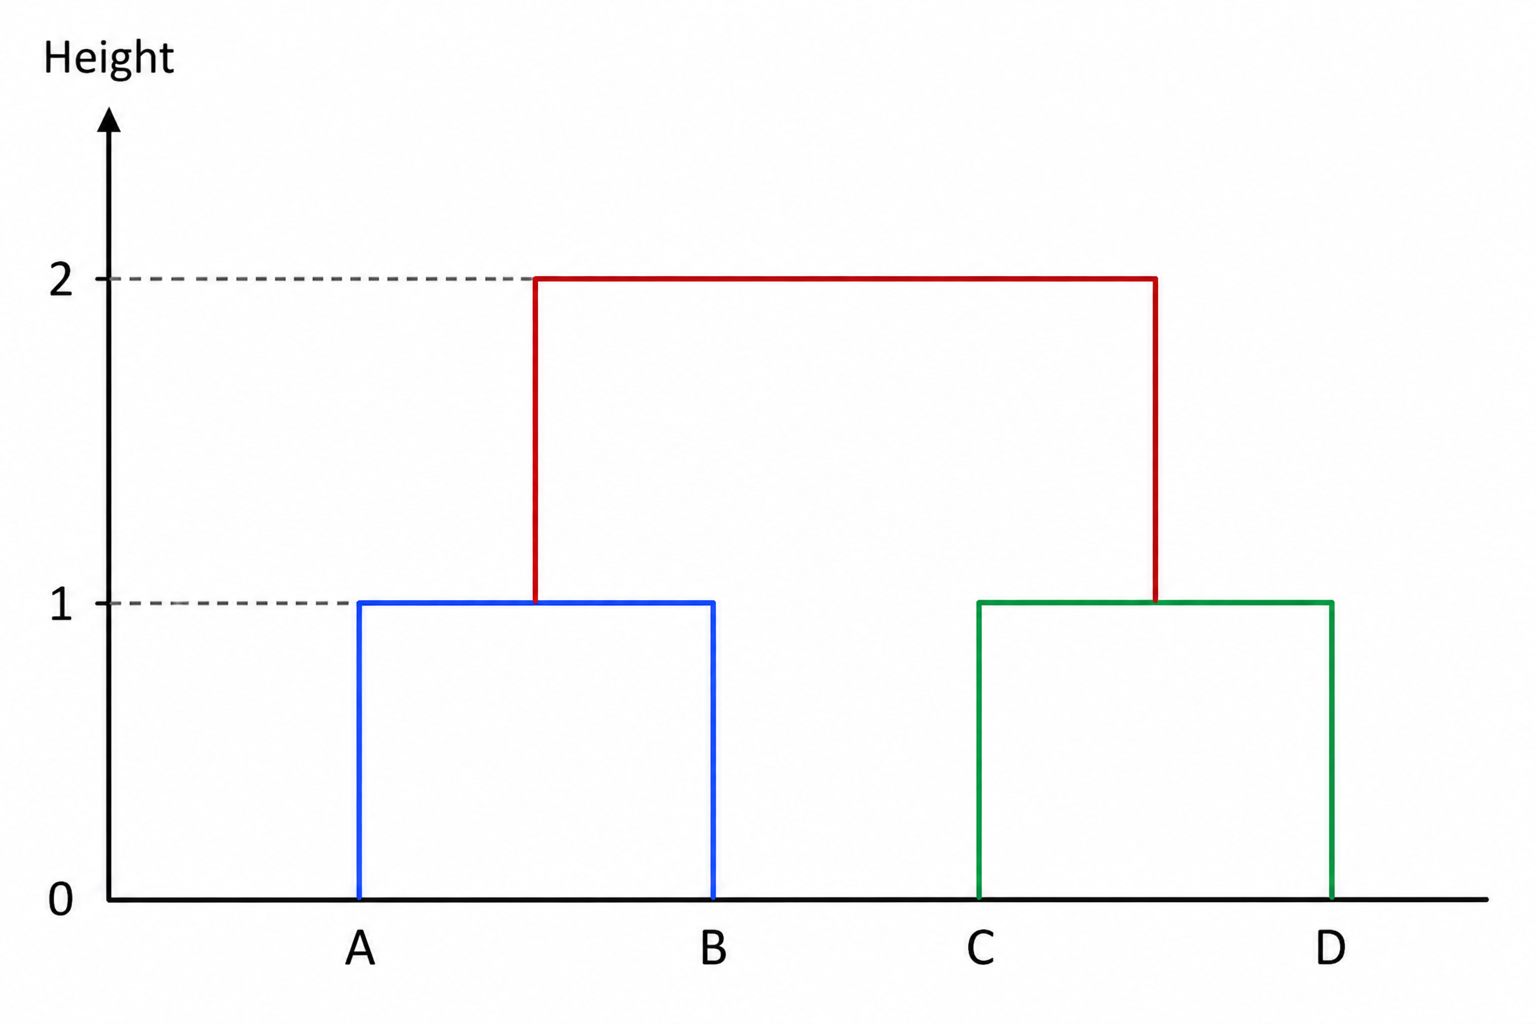

Cut here:
```
(A,B)
(C,D)
```
Result:
```
K = 2
```

### Linkage Methods

This is the most important concept.

Question:
> After forming clusters, how is distance between clusters measured?

Different answers produce different clusters.

#### 1. Single Linkage
Nearest Neighbor

Distance between clusters:
```
Minimum distance
```
Formula:
$$
D(A,B)=min(d(x,y))
$$

Example
```
Cluster A:
1,2

Cluster B:
8,9
```

Distances:
```
1→8 = 7
1→9 = 8
2→8 = 6
2→9 = 7
```

Minimum:
```
6
```

Cluster distance:
```
6
```

**Advantage**
- Finds irregular shapes.

**Disadvantage**
- Chaining Effect
```
A----B----C----D----E
```
Can connect distant groups through intermediate points.

#### 2. Complete Linkage
Farthest Neighbor

Distance:
```
Maximum distance
```
Formula:
$$
D(A,B)=max(d(x,y))
$$

Example:
```
Distances:
7
8
6
7
```

Maximum:
```
8
```

Cluster distance:
```
8
```

**Advantage**
- Produces compact clusters.

**Disadvantage**
- Sensitive to outliers.

#### 3. Average Linkage
Average of all pairwise distances.

Formula:
$$
D(A,B)= \frac{\sum{d(x,y)}}{N}
$$	​

Example:
```
7
8
6
7
```

Average:
```
7
```

**Advantage**
Balanced approach.

Widely used.

#### 4. Ward Linkage
Most popular in industry.

Instead of distance:

Measures increase in cluster variance.

Goal:
```
Minimize within-cluster variance
```

Similar philosophy to K-Means.

Produces highly compact clusters.

### Comparison of Linkage Methods
| Method   | Behavior              |
| -------- | --------------------- |
| Single   | Closest points        |
| Complete | Farthest points       |
| Average  | Mean distance         |
| Ward     | Variance minimization |

### Herarchical vs K-Means
| Feature           | K-Means  | Hierarchical |
| ----------------- | -------- | ------------ |
| Need K beforehand | Yes      | No           |
| Centroids         | Yes      | No           |
| Dendrogram        | No       | Yes          |
| Scalability       | Better   | Worse        |
| Interpretability  | Moderate | High         |

### Computational Complexity
Major limitation.

Agglomerative clustering:
$$
O(n^2)
$$
memory.

Sometimes:
$$
O(n^3)
$$
time.

Large datasets become difficult.

### Advantages
- No need for K initially
- Highly interpretable
- Dendrogram visualization
- Works with small datasets
- Captures hierarchical structure

### Limitations
- Computationally expensive
- Difficult on millions of samples
- Sensitive to noise
- Once merged, cannot undo merge

Important:

Agglomerative clustering is greedy.

Wrong early merge:
```
Cannot be corrected later
```

### Scaling Requirement
Like K-Means:

Distance-based.

Must scale features.

Typically:
```
StandardScaler()
```

### Problem Statement
An e-commerce company has **15 million registered customers** and sells products across multiple categories such as electronics, fashion, groceries, home appliances, and luxury goods.

The marketing team currently uses simple rule-based segmentation:
```
Premium Customers
Regular Customers
Inactive Customers
New Customers
```

However, these broad segments are insufficient because customer behavior varies significantly within each category.

For example:
```
Premium Customers
│
├── Luxury Brand Buyers
├── Frequent Small-Purchase Buyers
├── High-Value Electronics Buyers
└── Seasonal Big-Spenders
```

The business wants to:
1. Discover naturally occurring customer groups.
1. Understand relationships between customer groups.
1. Identify sub-segments inside larger segments.
1. Create personalized marketing campaigns.
1. Improve customer retention and revenue.

The number of customer groups is unknown beforehand.

#### Why Hierarchical Clustering?
K-Means requires:
```
Number of clusters (K)
```
before training.

Business stakeholders do not know:
```
K = 5 ?
K = 10 ?
K = 20 ?
```
Hierarchical Clustering solves this by:
```
Building the entire customer hierarchy
```
and allowing business teams to decide the appropriate level later.

This problem exhibits all conditions where Hierarchical Clustering excels:
- No predefined number of clusters
- Need to discover hidden customer segments
- Need hierarchical relationships between segments
- Need business interpretability through dendrograms
- Need executive-level and detailed segment views simultaneously

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import MiniBatchKMeans

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

import matplotlib.pyplot as plt

import joblib
import os
import time

In [2]:
DATA_PATH = "./data/customer_segmentation_enriched_dataset.csv"

SAMPLE_SIZE = 5000
OPTIMAL_K = 3

OUTPUT_DIR = "project-hierarchical_clustering"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5000, 11)


,Customer_ID,Annual_Spend,Order_Count,Avg_Order_Value,Days_Since_Last_Purchase,Product_Category_Count,Mobile_App_Usage,Website_Visits,Wishlist_Items,Coupon_Usage_Rate,Return_Rate
0,CUST_000001,84770.25,104,9216.24,220,3,29,73,78,0.124,0.137
1,CUST_000002,54350.82,129,13380.85,89,12,114,49,37,0.507,0.003
2,CUST_000003,94219.46,56,21822.28,231,16,105,9,36,0.052,0.207
3,CUST_000004,173880.04,118,17246.89,322,12,38,102,91,0.321,0.210
4,CUST_000005,50822.41,132,2967.24,257,8,4,93,74,0.621,0.048


In [5]:
# Feature Selection
feature_columns = [
    "Annual_Spend",
    "Order_Count",
    "Avg_Order_Value",
    "Days_Since_Last_Purchase",
    "Product_Category_Count",
    "Mobile_App_Usage",
    "Website_Visits",
    "Wishlist_Items",
    "Coupon_Usage_Rate",
    "Return_Rate"
]

X = df[feature_columns]

In [7]:
# Handle Missing Values
X = X.fillna(X.median())

In [8]:
# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    f"{OUTPUT_DIR}/scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [9]:
sample_df = df.sample(
    n=SAMPLE_SIZE,
    random_state=42
)

X_sample = scaler.transform(
    sample_df[feature_columns]
)

print(f"Sample Shape: {X_sample.shape}")

Sample Shape: (5000, 10)


In [10]:
# Build Dendrogram
print("Generating Dendrogram...")

start = time.time()

linked = linkage(
    X_sample,
    method="ward"
)

print(
    f"Dendrogram Linkage Time: "
    f"{time.time()-start:.2f} seconds"
)

plt.figure(figsize=(20,10))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Sampled Customers")
plt.ylabel("Distance")

plt.savefig(
    f"{OUTPUT_DIR}/dendrogram.png",
    bbox_inches="tight"
)

plt.close()

print("Dendrogram Saved")

Generating Dendrogram...
Dendrogram Linkage Time: 0.20 seconds
Dendrogram Saved


In [11]:
# Hierarchical Clustering on Sample
start = time.time()

sample_clusters = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage="ward"
).fit_predict(X_sample)

print(
    f"Hierarchical Clustering Time: "
    f"{time.time()-start:.2f} seconds"
)

sample_df["Cluster"] = sample_clusters

Hierarchical Clustering Time: 0.20 seconds


In [12]:
# Train K-Means on full dataset
print("Training MiniBatch KMeans...")

start = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=OPTIMAL_K,
    batch_size=1024,
    random_state=42
)

full_clusters = kmeans.fit_predict(
    X_scaled
)

print(
    f"KMeans Training Time: "
    f"{time.time()-start:.2f} seconds"
)

Training MiniBatch KMeans...
KMeans Training Time: 0.03 seconds


In [13]:
joblib.dump(
    kmeans,
    f"{OUTPUT_DIR}/customer_segmentation.pkl"
)

print("Model Saved")

Model Saved


In [14]:
# Assign Clusters
df["Cluster"] = full_clusters

In [15]:
# Save Clustered Data
df.to_csv(
    f"{OUTPUT_DIR}/clustered_customers.csv",
    index=False
)

print("Clustered Dataset Saved")

Clustered Dataset Saved


In [16]:
# Clustering Profiling
cluster_summary = (
    df.groupby("Cluster")[feature_columns]
    .mean()
    .round(2)
)

cluster_summary["Customer_Count"] = (
    df.groupby("Cluster").size()
)

cluster_summary.to_csv(
    f"{OUTPUT_DIR}/cluster_summary.csv"
)

print("\nCluster Summary")
print(cluster_summary)


Cluster Summary
         Annual_Spend  Order_Count  Avg_Order_Value  Days_Since_Last_Purchase  \
Cluster                                                                         
0           212879.64       120.00         12000.09                    171.47   
1            61134.47       131.82         13819.76                    156.52   
2            61841.47       116.59         11572.65                    204.19   

         Product_Category_Count  Mobile_App_Usage  Website_Visits  \
Cluster                                                             
0                         11.22             60.07           98.13   
1                         11.23             60.00          140.63   
2                         14.14             58.95           59.30   

         Wishlist_Items  Coupon_Usage_Rate  Return_Rate  Customer_Count  
Cluster                                                                  
0                 47.76               0.52         0.20             501  
1        

In [17]:
# Cluster Distribution
plt.figure(figsize=(8,5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")

plt.savefig(
    f"{OUTPUT_DIR}/cluster_distribution.png"
)

plt.close()

print("Distribution Plot Saved")

Distribution Plot Saved


In [18]:
cluster_summary = (
    df.groupby("Cluster")
      .agg({
          "Annual_Spend": "mean",
          "Order_Count": "mean",
          "Avg_Order_Value": "mean"
      })
)

print(cluster_summary)

          Annual_Spend  Order_Count  Avg_Order_Value
Cluster                                             
0        212879.643892   120.001996     12000.094990
1         61134.471160   131.817204     13819.761859
2         61841.468443   116.592413     11572.649916
